In [1]:
import os
import json
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression
import csv

In [2]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [3]:
# dataloader loads alphabetically, so we need to swap labels + adding FFT
class FFTImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        
        # Swap label: real=0, fake=1
        label = 1 - label
        
        fft = torch.fft.fft2(img, dim=(-2, -1))
        fft = torch.fft.fftshift(fft) 
        
        fft_mag = torch.abs(fft)
        
        fft_mag = torch.log1p(fft_mag)

        fft_mag = (fft_mag - fft_mag.mean()) / (fft_mag.std() + 1e-6)

        # Concatenate into a 6-channel tensor
        img_fft = torch.cat([img, fft_mag], dim=0)

        return img_fft, label

In [4]:
# Helper Functions

def subset_dataset(dataset, percent, seed=6050):
    if percent >= 1.0:
        return dataset
    
    random.seed(seed)
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

def plot_loss_and_acc(track_loss, track_train_acc, track_val_acc):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(track_train_acc, label="Train")
    plt.plot(track_val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(track_loss, label="Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def get_dataset_records(dataset, split_name):
    """
    Returns: list of dicts: {image_path, image_type, image_split}
    Works for both ImageFolder and Subset.
    """

    records = []

    # Determine base dataset (ImageFolder) and indices
    if isinstance(dataset, torch.utils.data.Subset):
        base = dataset.dataset
        indices = dataset.indices
    else:
        base = dataset
        indices = range(len(dataset))

    # Reverse mapping: 0→Real, 1→Fake
    label_map = {0: "real", 1: "fake"}

    # Collect rows
    for idx in indices:
        path, label = base.samples[idx]  # (full_path, original_label)

        # Apply label swap: real=0, fake=1
        correct_label = 1 - label
        label_name = label_map[correct_label]

        # Keep last 3 parts of path
        short_path = "/".join(Path(path).parts[-3:])

        records.append({
            "image_path": short_path,
            "image_type": label_name,
            "image_split": split_name
        })

    return records

def create_run_logger(model_name, params, timestamp, log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Create file paths
    log_txt = os.path.join(log_dir, f"{model_name}_run_{timestamp}.txt")
    log_json = os.path.join(log_dir, f"{model_name}_run_{timestamp}.json")

    # Initialize JSON log structure
    json_log = {
        "timestamp": timestamp,
        "model": model_name,
        "parameters": params,
        "epoch_data": []
    }

    # Write initial text header
    with open(log_txt, "w") as f:
        f.write("TRAINING RUN START \n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Model: {model_name}\n")
        f.write("\nPARAMETERS \n")
        for k, v in params.items():
            f.write(f"{k}: {v}\n")
        f.write("\n==============================\n\n")

    return log_txt, log_json, json_log

def show_jpeg_transform_effect(dataset, index, jpeg_transform):
    # Load image according to dataset structure
    if isinstance(dataset, torch.utils.data.Subset):
        original_idx = dataset.indices[index]
        path = dataset.dataset.samples[original_idx][0]
        pil_img = Image.open(path).convert("RGB")
        label = dataset[ index ][1]
    else:
        path = dataset.samples[index][0]
        pil_img = Image.open(path).convert("RGB")
        label = dataset[index][1]
        
    # Apply your RandomJPEGCompression transform
    compressed_img = jpeg_transform(pil_img)

    # Plot original vs. compressed
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    axs[0].imshow(pil_img)
    axs[0].set_title(f"Original\n{os.path.basename(path)}")
    axs[0].axis("off")

    axs[1].imshow(compressed_img)
    axs[1].set_title(f"JPEG Transform Applied\nClass={label}")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

def loading_data(train_dir, val_dir, transform, train_ratio = 1.0, batch_size=32, num_workers=0):

    # train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
    # val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

    train_dataset = FFTImageFolder(root=str(train_dir), transform=transform)
    val_dataset   = FFTImageFolder(root=str(val_dir), transform=transform)

    print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

    if train_ratio >= 1.0 or train_ratio <= 0.0:
        print("Using all the data")
    else:
        train_dataset = subset_dataset(train_dataset, train_ratio)
        val_dataset = subset_dataset(val_dataset, train_ratio)
        print(f"Using {train_ratio*100}% of the data")

    #DATALOADERS
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

    # logging data splits
    train_records = get_dataset_records(train_dataset, "train")
    val_records = get_dataset_records(val_dataset, "validation")

    all_records = train_records + val_records

    csv_datetime = datetime.now().strftime('%Y%m%d_%H%M%S')
    csv_name = f"dataset_split_{csv_datetime}.csv"
    csv_path = f"logs/{csv_name}"

    os.makedirs("logs", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["image_path", "image_type", "image_split"])
        writer.writeheader()
        writer.writerows(all_records)

    print(f"Saved dataset split CSV to: {csv_path}")
    print(f"Total records: {len(all_records)}")

    return train_loader, val_loader, train_dataset, val_dataset, csv_name

# dataloader loads alphabetically, so we need to swap labels
class CustomImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        # Swap label: make 'real' = 0, 'fake' = 1
        label = 1 - label
        return img, label


In [5]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 1
learning_rate = 1e-4
train_percent = 1.0

In [6]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ViT
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(quality_range=(30, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 256x256
randomcrop will random crop a 224x224 image from the 256x256 image
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 256x256\nrandomcrop will random crop a 224x224 image from the 256x256 image\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [7]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = loading_data(train_dir, 
                                                                    val_dir, 
                                                                    transform, 
                                                                    train_ratio = train_percent,
                                                                    batch_size=batch_size, 
                                                                    num_workers=0)

Original class mapping: {'fake': 0, 'real': 1}
Using all the data
Training on 115200 images, validating on 28340 images.
Saved dataset split CSV to: logs/dataset_split_20251201_073145.csv
Total records: 143540


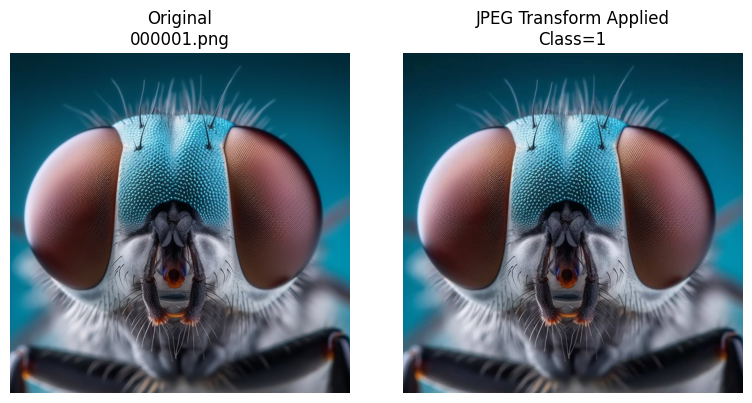

In [8]:
jpeg_aug = RandomJPEGCompression(quality_range=(5, 60))
show_jpeg_transform_effect(val_dataset, 0, jpeg_aug)

In [9]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000001.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000002.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000003.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000004.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000006.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000008.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000012.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000013.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000014.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000017.png --> Label: 1


In [10]:
# MODEL SETUP ViT

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

old_conv = model.conv_proj
new_conv = nn.Conv2d(
    in_channels=6,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=(old_conv.bias is not None),
)

with torch.no_grad():
    new_conv.weight[:, :3, :, :] = old_conv.weight # RGB weights
    new_conv.weight[:, 3:, :, :] = old_conv.weight

    if old_conv.bias is not None:
        new_conv.bias.copy_(old_conv.bias)

model.conv_proj = new_conv

model.heads.head = nn.Sequential(
    nn.LayerNorm(model.heads.head.in_features),
    nn.Linear(model.heads.head.in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)


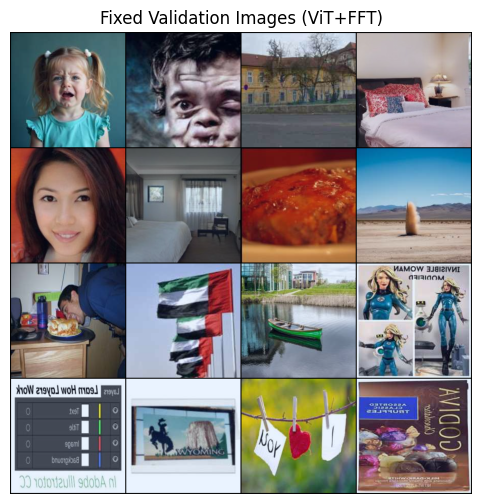

Fake: 023502.png
Fake: 000658.png
Fake: 033563.png
Fake: 021686.png
Fake: 020622.png
Fake: 001097.png
Fake: 035166.png
Fake: 019202.png
Real: 000000432085.jpg
Real: 0021933.png
Real: 000000311518.jpg
Real: 0011326.png
Real: 0027161.png
Real: 0020339.png
Real: 0023977.png
Real: 0016957.png


In [11]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

#UPDATE FOR FFT
fixed_rgb = fixed_images[:, :3, :, :]   # shape (N, 3, H, W)

grid_img = make_grid(fixed_rgb.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images (ViT+FFT)")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [12]:
# Training loop with logging

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs,
                model_name=None, csv_name_used = None):
    
    timestamp_pth = datetime.now().strftime("%Y%m%d_%H%M%S")

    if model_name is None:
        model_name = "No model name provided"

    if csv_name_used is None:
        csv_name_used = "none provided"

    params = {
        "model": model_name,
        "dataset split used:": csv_name_used,
        "epochs_per_step": num_epochs,
        "batch_size": batch_size,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    log_txt, log_json, json_log = create_run_logger(model_name, params, timestamp_pth)

    # Log device + dataset sizes
    device_info = str(device)
    if device.type == "cuda":
        device_info += f" ({torch.cuda.get_device_name(0)})"
        print(f"Using device: {device_info}")
    else:
        device_info += " (CPU)"
        print(f"Using device: {device_info}")

    with open(log_txt, "a") as f:
        f.write(f"Using device: {device_info}\n")
        f.write(f"Using dataset: {csv_name_used}\n")
        f.write(f"Using model: {model_name }\n")
        f.write(f"Using epochs per step: {num_epochs}\n")
        f.write(f"Using batch size: {batch_size}\n")
        f.write(f"Using learning rate: {optimizer.param_groups[0]['lr']}\n")
        f.write(f"Training samples: {len(train_loader.dataset)}\n")
        f.write(f"Validation samples: {len(val_loader.dataset)}\n\n")

    # Training setup
    best_val_acc = 0.0
    start_time = time.time()

    track_loss = []
    track_train_acc = []
    track_val_acc = []

    # Epoch loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\n - Epoch {epoch+1}/{num_epochs}")

        # Wrap train loader with tqdm
        train_pbar = tqdm(train_loader, desc="Training", unit="batch")
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            train_acc = 100 * correct / total
            avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)

            # Live update progress bar
            train_pbar.set_postfix({
                "Loss": f"{avg_loss:.4f}",
                "Train Acc": f"{train_acc:.2f}%"
            })

        # Validation Pass
        model.eval()
        val_correct = 0
        val_total = 0
        val_pbar = tqdm(val_loader, desc="Validating", unit="batch", leave=False)

        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)

                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

            outputs_grid = model(fixed_images)
            preds_grid = torch.argmax(outputs_grid, dim=1)

        val_acc = 100 * val_correct / val_total

        # Create epoch visualization
        label_names = ['Real', 'Fake']
        true_names = [label_names[l.item()] for l in fixed_labels]
        pred_names = [label_names[p.item()] for p in preds_grid]

        fig, axs = plt.subplots(3, 1, figsize=(8, 8))

        fixed_images_vis = fixed_images[:, :3, :, :].cpu()
        grid_img = make_grid(fixed_images_vis, nrow=grid_size, normalize=True)
        

        axs[0].imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
        axs[0].set_title("Validation Samples")
        axs[0].axis("off")

        img_w = grid_img.shape[2] // grid_size
        img_h = grid_img.shape[1] // grid_size

        axs[1].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
        axs[1].set_title("True Labels")
        axs[1].axis("off")
        for i, lbl in enumerate(true_names):
            axs[1].text((i % grid_size + 0.5) * img_w,
                        (i // grid_size + 0.5) * img_h,
                        lbl, ha='center', va='center', fontsize=14)

        axs[2].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
        axs[2].set_title("Predicted Labels")
        axs[2].axis("off")
        for i, lbl in enumerate(pred_names):
            color = 'green' if lbl == true_names[i] else 'red'
            axs[2].text((i % grid_size + 0.5) * img_w,
                        (i // grid_size + 0.5) * img_h,
                        lbl, ha='center', va='center', fontsize=14, color=color)

        plt.tight_layout()
        plt.show()

        # Logging epoch data
        with open(log_txt, "a") as f:
            f.write(f"Epoch {epoch+1}/{num_epochs}\n")
            f.write(f"  Loss: {avg_loss:.4f}\n")
            f.write(f"  Train Acc: {train_acc:.2f}%\n")
            f.write(f"  Val Acc: {val_acc:.2f}%\n\n")

        json_log["epoch_data"].append({
            "epoch": epoch + 1,
            "loss": avg_loss,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_{model_name}_{timestamp_pth}.pth")

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
        track_loss.append(avg_loss)
        track_train_acc.append(train_acc)
        track_val_acc.append(val_acc)

    # Final log summary
    total_minutes = (time.time() - start_time) / 60

    with open(log_txt, "a") as f:
        f.write("\nTRAINING COMPLETE \n")
        f.write(f"Total time: {total_minutes:.2f} minutes\n")
        f.write(f"Best Validation Accuracy: {best_val_acc:.2f}%\n")
        f.write(f".pth saved as best_{model_name}_{timestamp_pth}.pth")

    json_log["total_minutes"] = total_minutes
    json_log["best_val_acc"] = best_val_acc

    with open(log_json, "w") as f:
        json.dump(json_log, f, indent=4)

    print(f"Logs saved to:\n  {log_txt}\n  {log_json}")

    print(f"\nTraining complete in {(time.time() - start_time)/60:.2f} minutes.")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    plot_loss_and_acc(track_loss, track_train_acc, track_val_acc)

    return track_loss, track_train_acc, track_val_acc


Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

 - Epoch 1/5


Training: 100%|██████████| 3600/3600 [35:15<00:00,  1.70batch/s, Loss=0.4841, Train Acc=80.16%]


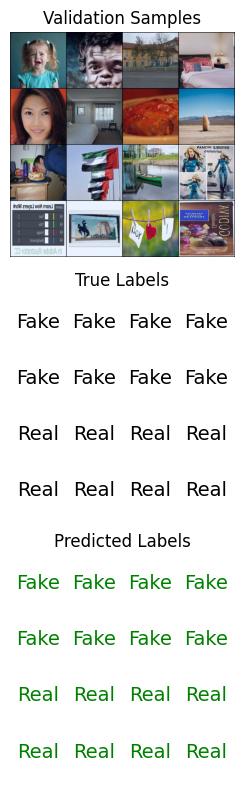

Epoch 1/5 Loss: 0.4841 | Train Acc: 80.16% | Val Acc: 82.60%

 - Epoch 2/5


Training: 100%|██████████| 3600/3600 [39:04<00:00,  1.54batch/s, Loss=0.4682, Train Acc=81.64%]


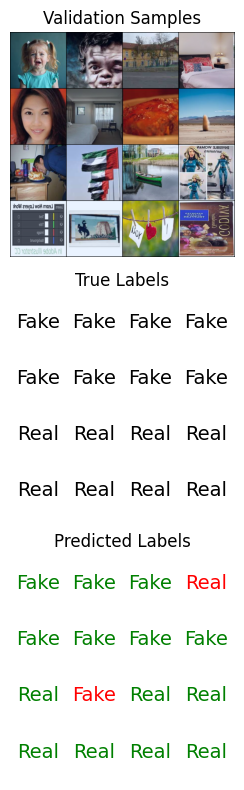

Epoch 2/5 Loss: 0.4682 | Train Acc: 81.64% | Val Acc: 83.10%

 - Epoch 3/5


Training: 100%|██████████| 3600/3600 [30:14<00:00,  1.98batch/s, Loss=0.4618, Train Acc=82.14%]


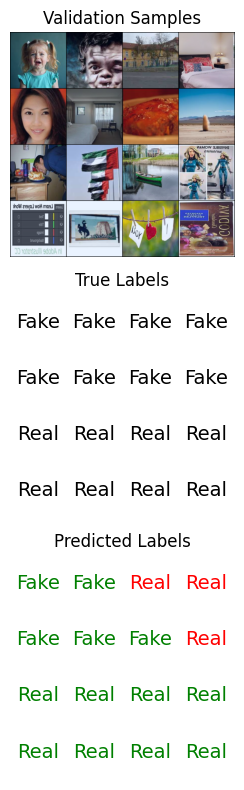

Epoch 3/5 Loss: 0.4618 | Train Acc: 82.14% | Val Acc: 75.52%

 - Epoch 4/5


Training: 100%|██████████| 3600/3600 [31:55<00:00,  1.88batch/s, Loss=0.4553, Train Acc=82.45%]


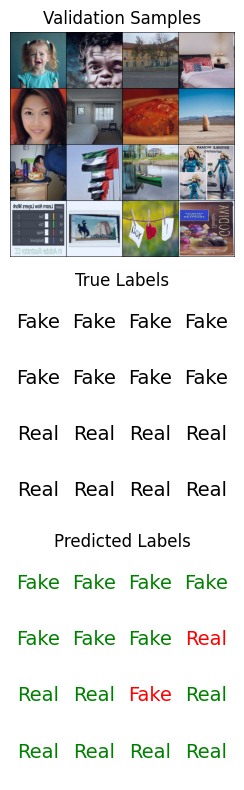

Epoch 4/5 Loss: 0.4553 | Train Acc: 82.45% | Val Acc: 83.26%

 - Epoch 5/5


Training: 100%|██████████| 3600/3600 [31:24<00:00,  1.91batch/s, Loss=0.4474, Train Acc=83.29%]


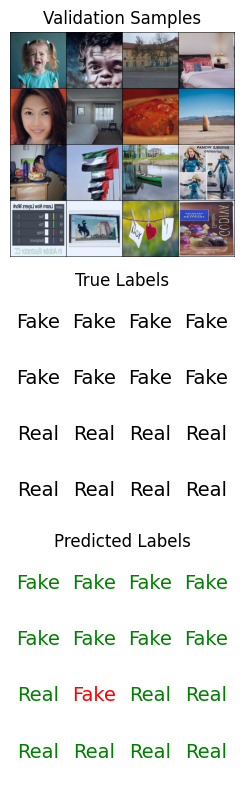

Epoch 5/5 Loss: 0.4474 | Train Acc: 83.29% | Val Acc: 83.64%
Logs saved to:
  logs\ViT+FFT_run_20251201_073147.txt
  logs\ViT+FFT_run_20251201_073147.json

Training complete in 193.64 minutes.
Best validation accuracy: 83.64%


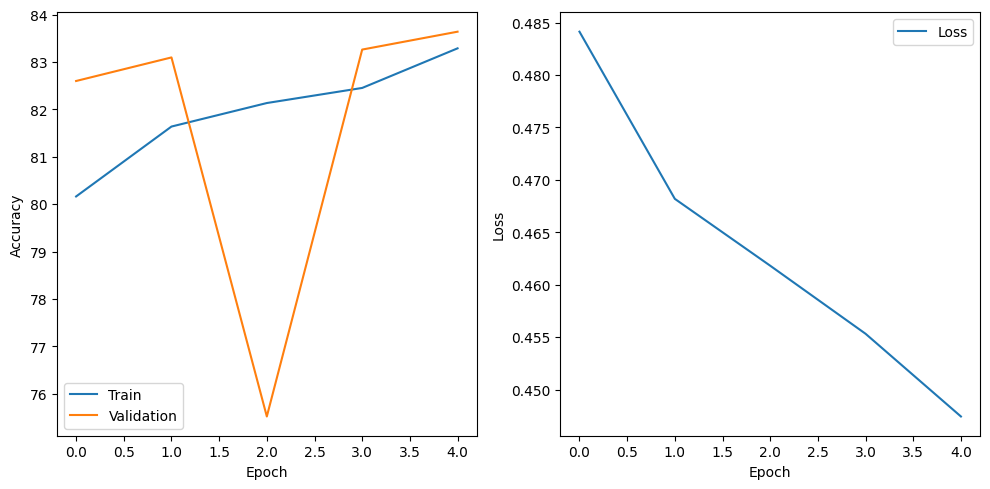

In [13]:
all_metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5,
                          model_name="ViT+FFT", csv_name_used=csv_name)